# **Random Forest**

In [ ]:
# Cria uma quantidade enorme de modelos fracos, e a medida que se juntam, as previsoes costumam ser mais robustas e proximas da realidade.
# Basicamente, cria-se varias arvores de decisoes, geradas de forma independente.
# Features selecionadas de forma aleatoria.
# Modelo de classificacao: voto da maioria.
# Cada arvore e treinada em uma amostra aleatoria de dados, com subtituicao (bootstrap)

In [ ]:
## Vantagens
# Lida com conjunto de dados grandes e com alta dimensionalidade
# Menos propenso ao overfitting em comparacao a decisoes individuais
# Fornece uma estimativa da importancia de cada atributo

## Desvantagens
# Mais complexo computacionalmente e requer mais recursos
# Menos interpretavel do que uma unica arvore de decisao
# Sensivel a hiperparametros e ajustes

In [ ]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier

In [ ]:
# leitura de dados
df = pd.read_csv('diabetes.csv')
X = df.drop(columns=['Outcome'])
y = df['Outcome']

x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=101)

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# Instanciando e treinando o modelo
clf = RandomForestClassifier(random_state=101)
clf.fit(x_treino, y_treino)

pred = clf.predict(x_teste)

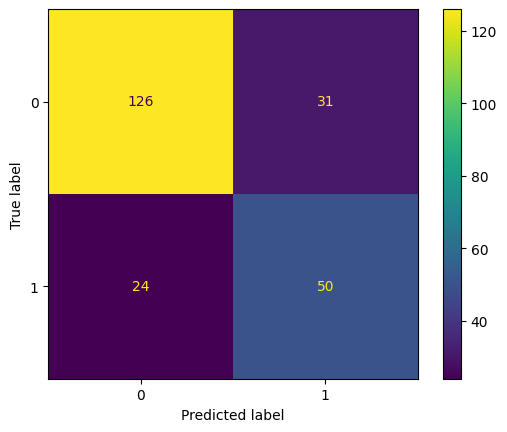

In [ ]:
# Avaliacao de modelo
matriz_confusao = confusion_matrix(pred, y_teste)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                             display_labels=clf.classes_)
disp.plot()
# Inicialmente, apesar de nao ter a maior acuracia, tem um grande numero de verdadeiros positivos, ponto positivo do modelo

In [ ]:
# Calculo de Acuracia
accuracy_score(pred, y_teste)
# Acuracia inicial de 76%

0.7619047619047619

In [ ]:
# Calculo da acuracia do treino
accuracy_score(clf.predict(x_treino), y_treino)

1.0

In [ ]:
# Ajuste de parametros do modelo
# n_estimators (numero de estimadores que sera construido)
# o padrao do n e 100
for n_estimators in range(10, 500, 5):
  clf = RandomForestClassifier(random_state=101,
                               n_estimators=n_estimators)
  clf.fit(x_treino, y_treino)
  pred = clf.predict(x_teste)
  acc = accuracy_score(pred, y_teste)

  if acc > 0.78:
    print('n_estimators =', n_estimators)
    print('Acuracia =', acc)
    print('='*100)
  # 10 estimadores ja foram suficiente para atingir uma acuracia maior

n_estimators = 10
Acuracia = 0.7835497835497836


In [ ]:
# Criterion
for criterion in ['gini', 'entropy', 'log_loss']:
  clf = RandomForestClassifier(random_state=101,
                               n_estimators=10,
                               criterion=criterion)
  clf.fit(x_treino, y_treino)
  pred = clf.predict(x_teste)
  acc = accuracy_score(pred, y_teste), accuracy_score(clf.predict(x_treino), y_treino)

  print('Criterion =', criterion)
  print('Acuracia =', acc)
  print('='*100)

Criterion = gini
Acuracia = (0.7835497835497836, 0.9776536312849162)
Criterion = entropy
Acuracia = (0.7445887445887446, 0.9683426443202979)
Criterion = log_loss
Acuracia = (0.7445887445887446, 0.9683426443202979)


In [ ]:
# max depth
for max_depth in range(2, 20):
  clf = RandomForestClassifier(random_state=101,
                               n_estimators=10,
                               criterion='gini',
                               max_depth=max_depth)

  clf.fit(x_treino, y_treino)
  pred = clf.predict(x_teste)
  acc = accuracy_score(pred, y_teste)

  if acc > 0.78:
    print('max_depth =', max_depth)
    print('Acuracia =', acc)
    print('='*100)
# com max depth 17, o desempenho foi superior

max_depth = 17
Acuracia = 0.7835497835497836
max_depth = 18
Acuracia = 0.7835497835497836
max_depth = 19
Acuracia = 0.7835497835497836


In [ ]:
# criacao do modelo final de Random Forest
clf = RandomForestClassifier(random_state=101,
                             n_estimators=10,
                             criterion='gini',
                             max_depth=17)
clf.fit(x_treino, y_treino)
pred = clf.predict(x_teste)
acc = accuracy_score(pred, y_teste)

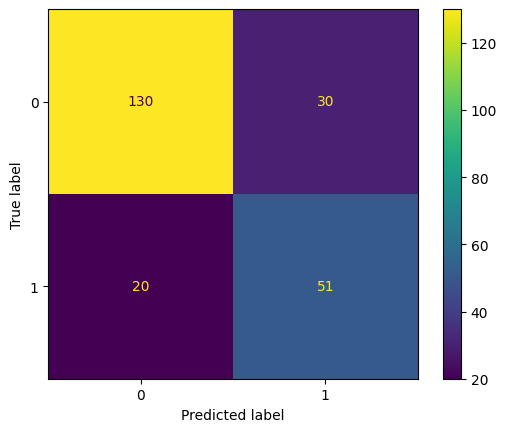

In [ ]:
# matriz de confusao
matriz_confusao = confusion_matrix(pred, y_teste)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao,
                              display_labels=clf.classes_)
disp.plot()
# com 78% de acuracia, foi o unico modelo que acertou uma quantidade de verdadeiros positivos proximo ao Naive Bayes, que acertou 52.
# Houve um incremento nas principais categorias apos ajustes de hiperparametros

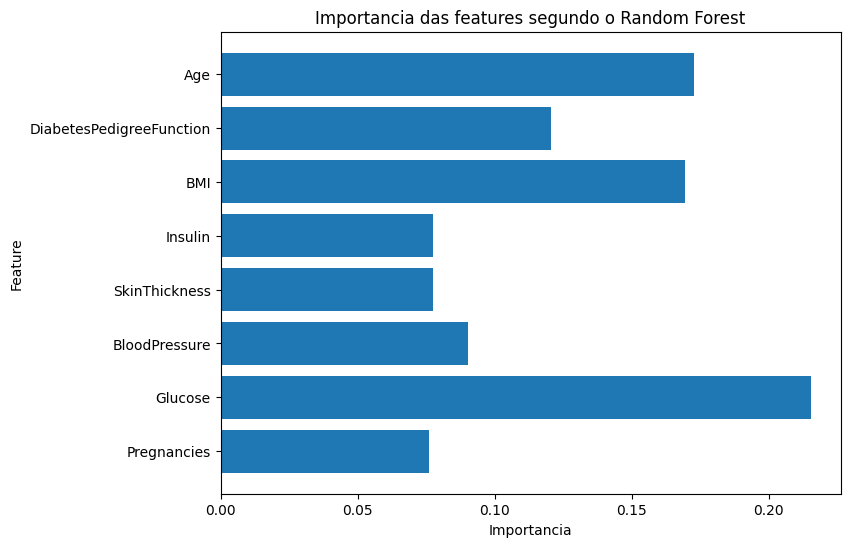

In [ ]:
# Feature Importance: importancia de cada feature na classificacao
feature_importance = clf.feature_importances_
#matplotlib

plt.figure(figsize=(8, 6)) # tamanho da figura
plt.barh(range(len(x_treino.columns)), #  eixo y tem comprimento das colunas de x, barra horizontal
         feature_importance, # importancia
         tick_label=x_treino.columns) # nome de cada feature

plt.xlabel('Importancia') # nome eixo x
plt.ylabel('Feature') # nome eixo y
plt.title('Importancia das features segundo o Random Forest') # titulo grafico
plt.show() # criacao do grafico

# Para o random forest, fica evidente que a feature mais importante e a de glicose, seguida de bmi (indice de massa corporea), idade e historico
# Reduzir a feature, diminui a complexidade do modelo
# Ou seja, e bom reduzir as features para reduzir a coleta de dados, gerando economia de custos